In [3]:

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches







In [4]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [5]:

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [6]:

def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False
def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [7]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

class GridProblem(Problem):
    def __init__(self, grid: List[List[int]], start: Tuple[int, int], goal: Tuple[int, int]):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1 fixed
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2 fixed
        legal_actions = []
        for action, (dr, dc) in MOVES.items():
            row, col = state
            new_state = (row + dr, col + dc)
            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3 fixed
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(self, state: Tuple[int, int], action: str, next_state: Tuple[int, int]) -> float:
        # TODO 4 fixed
        return 1


In [8]:


# 5.1 Self-Check for GridProblem

# Test grid:
# S . .
# # # .
# . . G

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

# Create the problem instance
test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

# Assertions to check correctness
assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")


GridProblem self-check passed.


In [9]:
# 6. Sample Drone Map
# The map below is provided so your lab can run without depending on an internet connection.
# You may still create your own maps later.

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

# Create the GridProblem instance with the sample map
problem = GridProblem(sample_grid, start, goal)

print("Sample Drone Map loaded successfully.")


Sample Drone Map loaded successfully.


In [10]:
# 7. Visualisation Helper
# This function plots:
# - obstacles as dark cells
# - the start position
# - the goal position
# - the solution path

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)  # obstacle
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)  # start
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)  # goal
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)  # path
            else:
                fill = (0.95, 0.95, 0.95)  # free cell

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


In [11]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5 fixed
        state = node.state
        for action in problem.actions(state):
            next_state = problem.result(state, action)
            cost = node.path_cost + problem.action_cost(state, action, next_state)
            yield Node(state=next_state, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [12]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # Step 1: Create the initial node
        node = Node(state=problem.initial_state())

        # Step 2: Check if initial state is the goal
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        # Step 3: Create frontier (FIFO queue) and add initial node
        frontier = deque([node])

        # Step 4: Create reached set and add initial state
        reached = {node.state}

        # Tracking stats
        nodes_expanded = 0
        max_frontier_size = 1

        # Step 5: While frontier is not empty
        while frontier:
            # a. Pop from LEFT of deque (FIFO)
            node = frontier.popleft()
            nodes_expanded += 1

            # b. Expand the node
            for child in self.expand(problem, node):
                s = child.state

                # i. If child is goal, return success
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                # ii. If not reached, add to reached and frontier
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            # c. Update max frontier size
            max_frontier_size = max(max_frontier_size, len(frontier))

        # Step 6: Return failure if no solution found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [13]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # Step 1: Create the initial node
        node = Node(state=problem.initial_state())

        # Step 2: Check if initial state is the goal
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        # Step 3: Use a Python list as the stack frontier
        frontier = [node]

        # Step 4: Create reached set
        reached = {node.state}

        # Tracking stats
        nodes_expanded = 0
        max_frontier_size = 1

        # Step 5: While frontier is not empty
        while frontier:
            # a. Pop from the end of the list (LIFO)
            node = frontier.pop()
            nodes_expanded += 1

            # b. Expand the node
            children = list(self.expand(problem, node))
            children.reverse()

            for child in children:
                s = child.state

                # i. If child is goal, return success
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                # ii. If not reached, add to reached and stack
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        # Step 6: Return failure
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [14]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8 fixed

        # Step 1: Goal test
        if problem.is_goal(node.state):
            return node, "success"

        # Step 2: Depth cutoff
        elif node.depth >= limit:
            return None, "cutoff"

        # Step 3: Expand children
        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            # i. Skip if child.state already on path
            if state_is_on_path(node, child.state):
                continue

            # ii. Update max stack size
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

            # iii. Recursive call
            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

            # iv. Success case
            if status == "success":
                return result, "success"

            # v. Cutoff case
            elif status == "cutoff":
                cutoff_occurred = True

        # Step 4: Return cutoff or failure
        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"


In [15]:
class IterativeDeepeningSearch(SearchAlgorithm):

    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iterations = []
        total_nodes_expanded = 0
        max_stack_size = 0
        total_reached = 0

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            iterations.append({
                "limit": limit,
                "status": result.status
            })

            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)
            total_reached += result.reached_count

            # SUCCESS
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=total_reached,
                    iterations=iterations,
                    limit=limit,
                )

            # FAILURE
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=total_reached,
                    iterations=iterations,
                    limit=limit,
                )

        # CUT-OFF
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=total_reached,
            iterations=iterations,
            limit=max_depth,
        )

In [16]:
# 13. Run the Algorithms on the Sample Map
# Complete all algorithm classes before running this section.
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()
results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)



,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


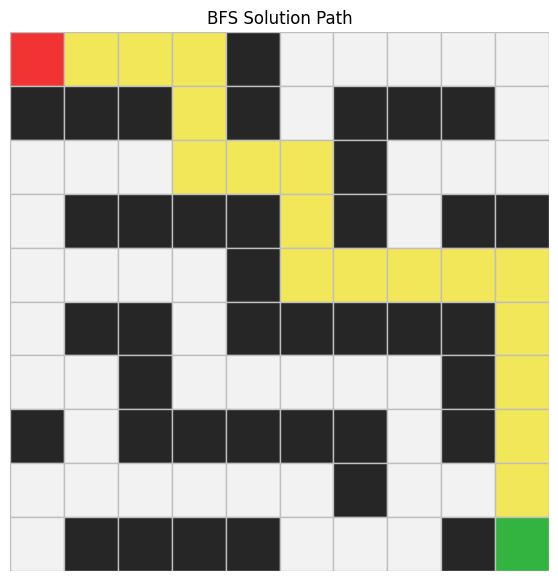

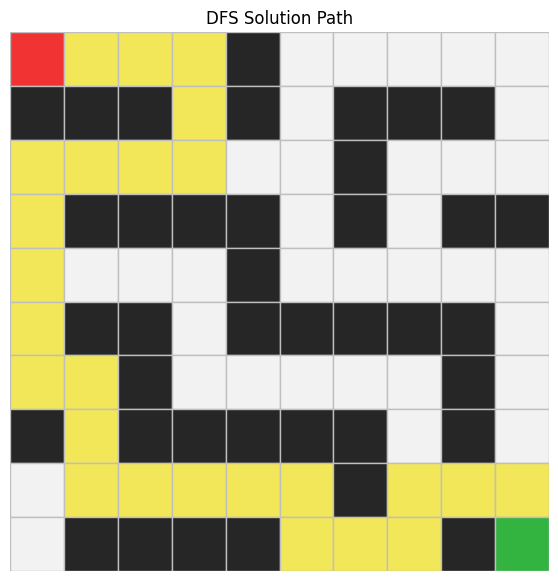

In [17]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

# Define results
results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

# Visualise solution paths
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [18]:
custom_grid_1 = [
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1  = (4, 4)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,8,8,8,1,8
1,DFS,success,NaN,8,8,8,1,8
2,DLS,success,20.0,8,8,8,9,0
3,IDS,success,8.0,8,8,36,9,0


In [19]:
# TODO 11:
# Map 2: Many dead ends — DFS is likely to waste time exploring dead ends

custom_grid_2 = [
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
]

custom_start_2 = (0, 0)
custom_goal_2  = (9, 9)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,22.0,22.0,42,3,43
1,DFS,success,NaN,22.0,22.0,55,2,55
2,DLS,cutoff,20.0,NaN,NaN,38,21,0
3,IDS,success,22.0,22.0,22.0,424,23,0


In [20]:
bfs_r = bfs.search(problem)
print("BFS:", bfs_r)

dfs_r = dfs.search(problem)
print("DFS:", dfs_r)

dls_r = dls.search(problem, limit=10)
print("DLS:", dls_r)

ids_r = ids.search(problem, max_depth=30)
print("IDS:", ids_r)

BFS: SearchResult(algorithm='BFS', status='success', solution=Node(state=(9, 9), parent=Node(state=(8, 9), parent=Node(state=(7, 9), parent=Node(state=(6, 9), parent=Node(state=(5, 9), parent=Node(state=(4, 9), parent=Node(state=(4, 8), parent=Node(state=(4, 7), parent=Node(state=(4, 6), parent=Node(state=(4, 5), parent=Node(state=(3, 5), parent=Node(state=(2, 5), parent=Node(state=(2, 4), parent=Node(state=(2, 3), parent=Node(state=(1, 3), parent=Node(state=(0, 3), parent=Node(state=(0, 2), parent=Node(state=(0, 1), parent=Node(state=(0, 0), parent=None, action=None, path_cost=0, depth=0), action='RIGHT', path_cost=1, depth=1), action='RIGHT', path_cost=2, depth=2), action='RIGHT', path_cost=3, depth=3), action='DOWN', path_cost=4, depth=4), action='DOWN', path_cost=5, depth=5), action='RIGHT', path_cost=6, depth=6), action='RIGHT', path_cost=7, depth=7), action='DOWN', path_cost=8, depth=8), action='DOWN', path_cost=9, depth=9), action='RIGHT', path_cost=10, depth=10), action='RIGHT'

15.1 Problem Formulation

1. What is a state?
A state is a tuple (row, column) where the drone is located or the row and column in which it is located. That is, (0,0) is the top left corner.

2. what is An action ?
A drone can move from one cell to another by one of the following actions: UP, DOWN, LEFT or RIGHT.

3. What does the function 'result' do?
The `result` function takes the state and the action, and returns the state resulting from the action taken on the state. For instance, RIGHT(0, 0) is (0, 1).

4. Why is it useful to separate the problem definition from the search algorithm?
It maintains the module organization and modularity of the code. The same search technique (BFS, DFS, etc.) can be used in any problem without changes simply replace the problem definition. For instance, the exact same BFS algorithm can be applied to a grid maze and land mines.
Any puzzle or map; anything where the problem states what states, actions, and goal test are required.
correctly. This separation also simplifies code testing, debugging and maintenance.

15.2 BFS

1. Why does BFS use a FIFO queue?
FIFO ensures the order of exploration of nodes is the same as their discovery (level by level). This makes sure that the shallower nodes are explored first.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
This will look at every node at depth 1, then at depth 2, at depth 2 then at depth 3, and so on. On the first time visiting the goal it should have taken the minimum  of steps possible.

3. What role does the reached set play in BFS?
It keeps a record of all states already visited and so the algorithm does not visit the same cell again. This prevents looping and re-exploration.  


 15.3 DFS

1. What is the use of stack in DFS?
A stack (LIFO) ensures that the most recent discovered node is always expanded first and thus that DFS does a deep search first and then backtracks — this is the main action of DFS.

2. Is DFS guaranteed to find the shortest path? Explain.
No. DFS continues to depth of one path and returns the first solution which it finds, which might not be the shorted path. It doesn't even try out all the equal-length paths first, then go deeper.

3. Under what conditions can DFS use less memory than BFS?
When the solution is deep in the tree. DFS will only retain the path being traversed, while BFS will have to keep track of all of the nodes at the current level (which may be quite large on a wide grid).

4. Under what conditions can DFS perform badly?
When the search space is large and many paths are very long to the goal and/or are dead-ends. Excessive amount of time can be spent looking in the sub-tree that it became stuck in before going back up.                                                                    

15.4 DLS


1. What happens when the depth limit is too small?
The algorithm returns a `"cutoff"` status ,it stops before it reaches the goal due to the solution being deeper than the allowed depth.

2. What is the meaning of `"cutoff"`?
Cutoff: Solution not found within the given depth limit, but the solution could be found at a deeper depth.

3. How is DLS different from ordinary DFS?
DLS is an extension of the above which will limit exploration to a certain depth (DLS), on reaching a node at this depth, no further exploration will be done. The limit is not there in ordinary DFS; it continues till a solution is reached or till it has used up all the paths.

4. Why do we use path-cycle checking in DLS?
To avoid the algorithm entering states that have already been visited along the path, avoiding infinite loops in graphs with cycles.                                     


  15.5 IDS

1. Why does IDS repeat DLS with increasing limits?
Since there is no set depth limit known beforehand. IDS begins with a starting depth of 0 and steps up by 1 at each turn of the loop, so that it will eventually reach as deep as the solution.

2. Why can IDS be complete even though DLS with a small limit is not?
IDS keeps incrementing the bound until it's able to find the solution. With fixed small limit, possible DLS may not reach the goal at all, but at least IDS will reach the goal at some time.

3. Why does IDS use less memory than BFS?
IDS executes DLS at every iteration, and just keeps the current path on the stack. With BFS, all the frontier nodes are kept for each level which can be exponentially large.

4. What is the cost of repeatedly searching from the root?
In each iteration, nodes which are near the root are re-expanded, so that the number of expanded nodes is increased. In practice however, the overhead is negligible since the majority of nodes are at the bottom.



15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another?
In a real drone mission, it is probably advisable to take one path rather than the other  depending on wind, buildings and trees, no fly zones, battery life, signal zones and more. Not all the time is the shortest path the safest path.

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

BFS. Will return the shortest path (as measured on an unweighted grid) since it visits the nodes level by level and returns the first path found.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

DLS (Depth-Limited Search). It lets you specify the maximum depth of the search the drone can perform, which may come in handy if you want the drone to search for anything at depth x or you want to save battery life by limiting the range of the drone being searched.

4. What limitations does this grid model have compared with real drone navigation?

The grid makes all the moves cost the same, but of course this isn't true as the terrain and wind influence travel time and energy.

- Dynamic obstacles real world contains moving objects or changing weather, etc.

This is a grid  in reality there are real drones flying in 3D space, with an altitude axis.

The grid is designed with perfect knowledge of the surroundings, real drones use sensors which may not be perfect or complete.